In [86]:
# Step 1: Load and explore the data
import pandas as pd
import matplotlib.pyplot as plt
# Load the Excel file
df = pd.read_excel('C:/Users/TEJ/Desktop/Excel/6 Edtech/edtech_platform_data_v2.xlsx', sheet_name='Enrollment Data')

# Basic checks
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values in each column:")
print(df.isnull().sum())

Shape (rows, columns): (6000, 17)

Column names:
['Student ID', 'Signup Date', 'Year', 'Month', 'City', 'City Tier', 'Age Group', 'Gender', 'Course Name', 'Subject Category', 'Grade Level', 'Plan Type', 'Mode of Learning', 'Enrollment Status', 'Completion %', 'Revenue (INR)', 'Course Rating']

First 5 rows:
  Student ID Signup Date  Year Month       City City Tier Age Group  Gender  \
0   STU12728  2021-01-01  2021   Jan     Mumbai    Tier 1       18+    Male   
1   STU10424  2021-01-01  2021   Jan     Mumbai    Tier 1       18+  Female   
2   STU14019  2021-01-01  2021   Jan   Guwahati    Tier 3      6-10    Male   
3   STU10181  2021-01-02  2021   Jan  Ahmedabad    Tier 1     11-14  Female   
4   STU13262  2021-01-02  2021   Jan    Chennai    Tier 1     15-17    Male   

              Course Name   Subject Category Grade Level Plan Type  \
0  Spoken English Mastery  Skill Development         All    Annual   
1      Class 6 Foundation  School Curriculum           6   Monthly   
2    R

In [87]:
city_tier_summary = df.groupby('City Tier').agg(
    Total_Students=('Student ID', 'nunique'),
    Total_Revenue=('Revenue (INR)', 'sum')
).reset_index()
city_tier_summary.to_csv('summary_city_tier.csv', index=False)
print(city_tier_summary.to_string(index=False))

City Tier  Total_Students  Total_Revenue
   Tier 1            3033    26936698.54
   Tier 2            2033    18915609.68
   Tier 3             934     8343544.74


In [88]:
funnel = df['Enrollment Status'].value_counts()
print("\nEnrollment Funnel:")
print(funnel)

# Only count students who actually converted past trial
converted = df[df['Enrollment Status'] != 'Trial - Not Converted']

churned_count = (converted['Enrollment Status'] == 'Churned').sum()
total_converted = len(converted)
churn_rate = (churned_count / total_converted) * 100

print(f"\nTotal converted customers: {total_converted}")
print(f"Churned: {churned_count}")
print(f"Churn Rate: {churn_rate:.1f}%")


Enrollment Funnel:
Enrollment Status
Active                   3130
Trial - Not Converted    1247
Completed                 929
Churned                   694
Name: count, dtype: int64

Total converted customers: 4753
Churned: 694
Churn Rate: 14.6%


In [89]:
city_tier_summary = df.groupby('City Tier').agg(
    Total_Students=('Student ID', 'nunique'),
    Total_Revenue=('Revenue (INR)', 'sum'),
    Avg_Completion=('Completion %', 'mean')
).round(1).reset_index()

city_tier_summary['Revenue_per_Student'] = (
    city_tier_summary['Total_Revenue'] / city_tier_summary['Total_Students']
).round(0)

print("\nRevenue by City Tier:")
print(city_tier_summary.to_string(index=False))


Revenue by City Tier:
City Tier  Total_Students  Total_Revenue  Avg_Completion  Revenue_per_Student
   Tier 1            3033     26936698.5            53.9               8881.0
   Tier 2            2033     18915609.7            52.9               9304.0
   Tier 3             934      8343544.7            53.6               8933.0


In [90]:
plan_summary = df.groupby('Plan Type').agg(
    Total_Students=('Student ID', 'nunique'),
    Total_Revenue=('Revenue (INR)', 'sum'),
    Avg_Revenue_per_Student=('Revenue (INR)', 'mean')
).round(1).reset_index()

print("\nRevenue by Plan Type:")
print(plan_summary.to_string(index=False))


Revenue by Plan Type:
Plan Type  Total_Students  Total_Revenue  Avg_Revenue_per_Student
   Annual            3032     44922945.0                  14816.3
  Monthly            1425      2189320.6                   1536.4
Quarterly            1543      7083587.4                   4590.8


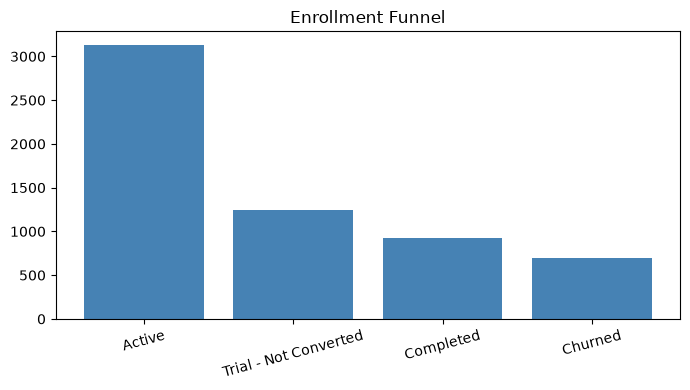

In [91]:
# Chart 1: Enrollment Funnel
plt.figure(figsize=(7, 4))
plt.bar(funnel.index, funnel.values, color='steelblue')
plt.title('Enrollment Funnel')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart1_funnel.png')

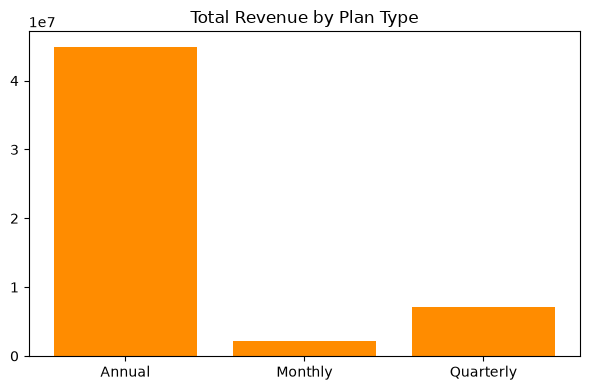

In [92]:
plt.figure(figsize=(6, 4))
plt.bar(plan_summary['Plan Type'], plan_summary['Total_Revenue'], color='darkorange')
plt.title('Total Revenue by Plan Type')
plt.tight_layout()
plt.savefig('chart3_revenue_plan_type.png')



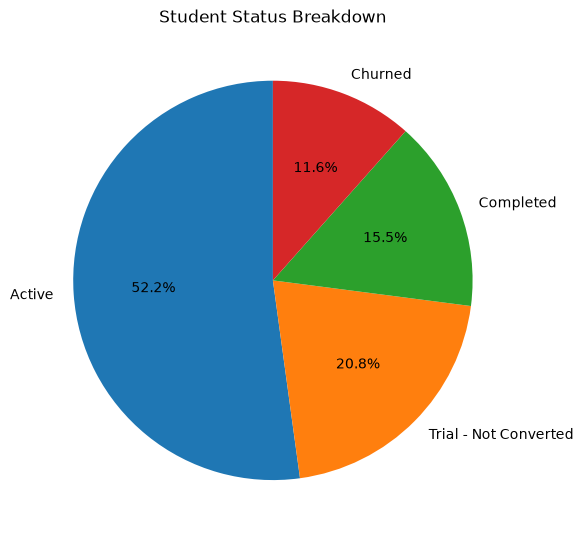

In [93]:
# Chart A: Pie Chart - Enrollment Status Breakdown
plt.figure(figsize=(6, 6))
plt.pie(funnel.values, labels=funnel.index, autopct='%1.1f%%', startangle=90)
plt.title('Student Status Breakdown')
plt.tight_layout()
plt.savefig('status_breakdown_pie.png')

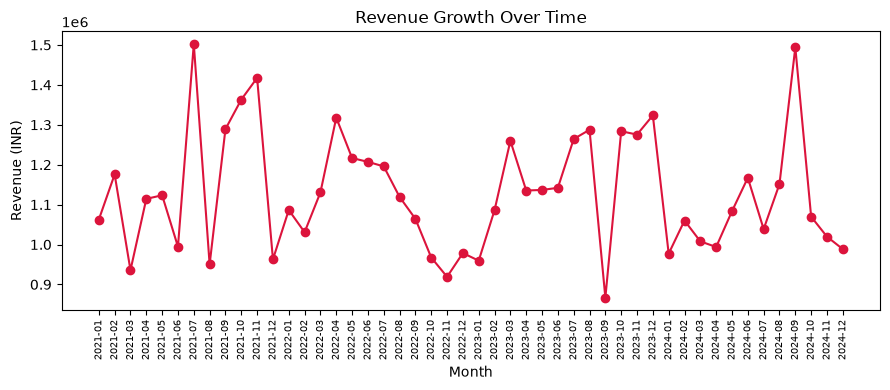

In [94]:
df['Year-Month'] = df['Signup Date'].dt.to_period('M').astype(str)
monthly_revenue = df.groupby('Year-Month')['Revenue (INR)'].sum().reset_index()

plt.figure(figsize=(9, 4))
plt.plot(monthly_revenue['Year-Month'], monthly_revenue['Revenue (INR)'], marker='o', color='crimson')
plt.title('Revenue Growth Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('revenue_growth_trend.png')

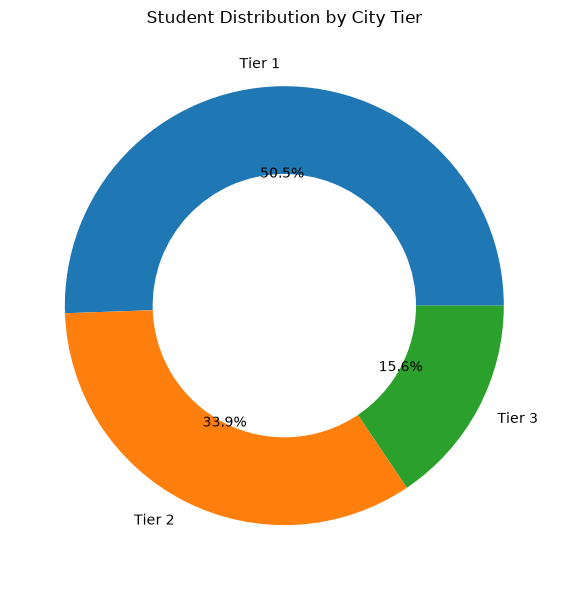

In [95]:
city_tier_counts = df.groupby('City Tier')['Student ID'].nunique()

plt.figure(figsize=(6, 6))
plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width': 0.4}
)
plt.title('Student Distribution by City Tier')
plt.tight_layout()
plt.savefig('donut_city_tier.png')

Saved: donut_city_tier.png and donut_mode_of_learning.png


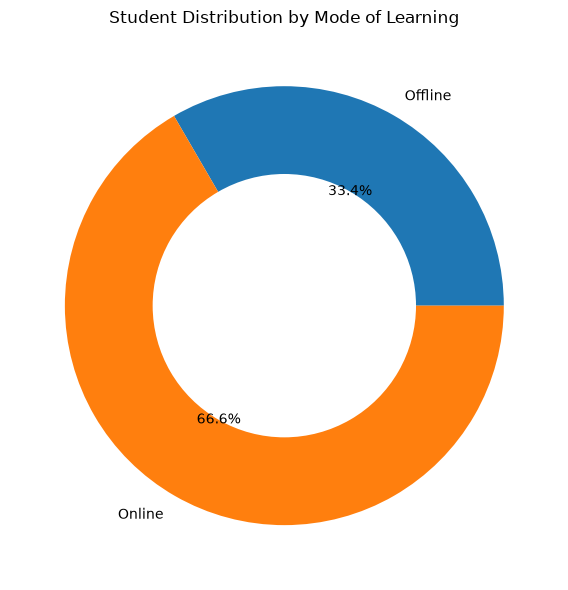

In [96]:
mode_counts = df.groupby('Mode of Learning')['Student ID'].nunique()

plt.figure(figsize=(6, 6))
plt.pie(
    mode_counts,
    labels=mode_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width': 0.4}
)
plt.title('Student Distribution by Mode of Learning')
plt.tight_layout()
plt.savefig('donut_mode_of_learning.png')

print("Saved: donut_city_tier.png and donut_mode_of_learning.png")